# FLUJO 1
- Simulo los datos
- Analizo la data
- Construyo la data que le pasare al modelo


# 1. Imports y rutas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import sys
from pathlib import Path
from datetime import datetime
import time
import pickle

# Modulos de simulacion (Algoritmos del anexo)
from model_psbp_fd.pipelines import (
    ConfigEscenario1,
    generar_escenario_1,
    guardar_escenario,
)

# Estandarizador data 
from model_psbp_fd.functions_models import DataStandardizer

# Modulos de representacion funcional 
from model_psbp_fd.functions_models import FunctionalRepresentation

# Modulos de utilidades
from model_psbp_fd.utils import get_project_root

# Módulos de visualización 
SYS_PATH_GRAPHICS = Path("graphics")
if str(SYS_PATH_GRAPHICS) not in sys.path:
    sys.path.insert(0, str(SYS_PATH_GRAPHICS))

from model_psbp_fd.graphics import (
    # viz_traces
    plot_traces_bj, plot_traces_pj,
    plot_convergence_bj, plot_convergence_pj,
    # viz_global_components
    plot_global_components, plot_active_clusters,
    # viz_functional_data
    plot_empirical_sample, plot_functional_mean,
    plot_functional_variance, plot_mean_and_variance,
    # viz_time_series
    plot_fts_empirical, plot_fts_functional, plot_fts_comparison,
    # viz_prediction
    plot_scatter_theta, plot_functional_comparison,
    # viz_preprocessing
    plot_diagnostico_estandarizacion, plot_seleccion_basis,
    # viz_fpca
    plot_fpca_scree, plot_fpca_correlacion_lag0, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline


## 1.1 Constantes a modificar según experimento 

In [2]:
# Buscamos la raiz del proyecto
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT : {PROJECT_ROOT}")


# IDENTIFICAR EL EXPERIMENTO: variables globales y rutas de salida
BASENAME      = "modelo_experimento_1"
TT            = 1
SEED          = 41232
#TIMESTAMP     = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPERIMENT_ID = f"{BASENAME}_{TT}"#_{TIMESTAMP}"      # Nombre del experimento 
print(f"Experiment ID : {EXPERIMENT_ID}")
print(f"Seed (base)   : {SEED}")

PROJECT_ROOT : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
Experiment ID : modelo_experimento_1_1
Seed (base)   : 41232


## 1.2 Construccion de Rutas

In [3]:
# Construccion de rutas 
_REPORT_DIR = PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID
_ARTEFACT_DIR = PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,                         # Datos: raw + estandarizados
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,    # Coeficientes funcionales + FPCA
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,       # Datos predichos
    "out_report":   _REPORT_DIR,          # Figuras + métricas/config JSON
    "out_artefact": _ARTEFACT_DIR,        # Artefactos (serializados, por experimento)
}
for name, path in PATHS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"  {name:10s} → {path}")

  raw        → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\modelo_experimento_1_1
  functional → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\modelo_experimento_1_1
  predict    → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\modelo_experimento_1_1
  out_report → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\modelo_experimento_1_1
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\modelo_experimento_1_1


# 2. Simulación

In [4]:
# CONSTANTES DE LA SIMULACION — Escenario 1 (Algoritmo 1 del anexo)

def media_senoidal(tau):
    """mu(tau) = 5 + 2 sin(2 pi tau). Definida con nombre para que quede
    registrada de forma legible en simulation_config.json."""
    return 5.0 + 2.0 * np.sin(2.0 * np.pi * tau)

SIM_CFG = ConfigEscenario1(
    # -- Esquema de observacion (comun a todos los escenarios) --
    L         = 50,       # puntos de la grilla regular
    T         = 150,      # curvas retenidas
    burn_in   = 200,      # calentamiento descartado
    sigma_obs = 0.5,      # desv. estandar del ruido de medicion
    R         = 1,        # replicas (flujo 1: una; estudio Monte Carlo: 50)
    seed      = SEED,
    media_fn  = media_senoidal,
    # -- Operador autorregresivo --
    gamma     = 0.3,      # alcance del nucleo gaussiano
    hs_norm   = 0.7,      # ||Psi||_HS objetivo; < 1 garantiza estacionariedad
    # -- Innovacion funcional --
    sigma_eps = 1.0,      # escala de la innovacion
    ell       = 0.2,      # longitud de correlacion (suavidad de trayectorias)
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<12}: {v}")


  L           : 50
  T           : 150
  burn_in     : 200
  sigma_obs   : 0.5
  R           : 1
  seed        : 41232
  media_fn    : media_senoidal
  jitter      : 1e-10
  gamma       : 0.3
  hs_norm     : 0.7
  sigma_eps   : 1.0
  ell         : 0.2


## 2.1 Simulación — Escenario 1: FAR(1) lineal gaussiano (Algoritmo 1 del anexo)


In [5]:
# ── Generación mediante el Escenario 1 ───────────────────────────────────────
salida = generar_escenario_1(SIM_CFG)

# El flujo 1 analiza UNA réplica; el estudio Monte Carlo completo itera sobre R.
REPLICA_IDX = 0
X_raw = salida.observaciones[REPLICA_IDX]          # (T, L): matriz observada
T, G  = X_raw.shape

# Alias de compatibilidad: el resto del notebook usa `domain.grid`
from types import SimpleNamespace
domain = SimpleNamespace(grid=salida.grilla)

print(f"Datos simulados : {X_raw.shape}  →  T={T} curvas, G={G} puntos")
print("Control de calidad del generador:")
for k, v in salida.diagnostico.items():
    print(f"  {k:30s} = {v}")

# ── Guardar configuración de simulación y grilla ─────────────────────────────
np.save(PATHS["raw"] / "domain_grid.npy", domain.grid)

simulation_config = {
    "sim_params":    salida.config.to_dict(),
    "diagnostico":   salida.diagnostico,
    "replica_idx":   REPLICA_IDX,
    "experiment_id": EXPERIMENT_ID,
    "seed":          SEED,
    "T":             int(T),
    "G":             int(G),
}
with open(PATHS["raw"] / "simulation_config.json", "w", encoding="utf-8") as _f:
    json.dump(simulation_config, _f, indent=2, ensure_ascii=False)

# Persistencia completa del escenario (todas las réplicas, formato .npz)
_npz = guardar_escenario(salida, str(PATHS["raw"] / "escenario_1"),
                         incluir_curvas=True, incluir_internos=True)

print(f"[raw] domain_grid.npy  ({domain.grid.shape})  → {PATHS['raw']}")
print(f"[raw] simulation_config.json             → {PATHS['raw']}")
print(f"[raw] escenario_1.npz (salida completa)  → {_npz}")


Datos simulados : (150, 50)  →  T=150 curvas, G=50 puntos
Control de calidad del generador:
  n_replicas                     = 1
  n_curvas                       = 150
  n_puntos_grilla                = 50
  todo_finito                    = True
  media_empirica_global          = 4.807831497627894
  media_ee_montecarlo            = nan
  var_puntual_media              = 1.3394575612269912
  var_puntual_min                = 0.9588055964616924
  var_puntual_max                = 1.7160086345254233
  acf1_media                     = 0.3766024134255682
  acf1_ee_montecarlo             = nan
  razon_senal_ruido              = 5.357830244907965
  hs_norm_objetivo               = 0.7
  hs_norm_efectiva               = 0.7
  hs_norm_error_absoluto         = 0.0
  radio_espectral_operador       = 0.6215281202598987
  estacionariedad_garantizada    = True
[raw] domain_grid.npy  ((50,))  → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\modelo_experimento_1_1
[raw

## 2.2 Visualización de los datos empíricos

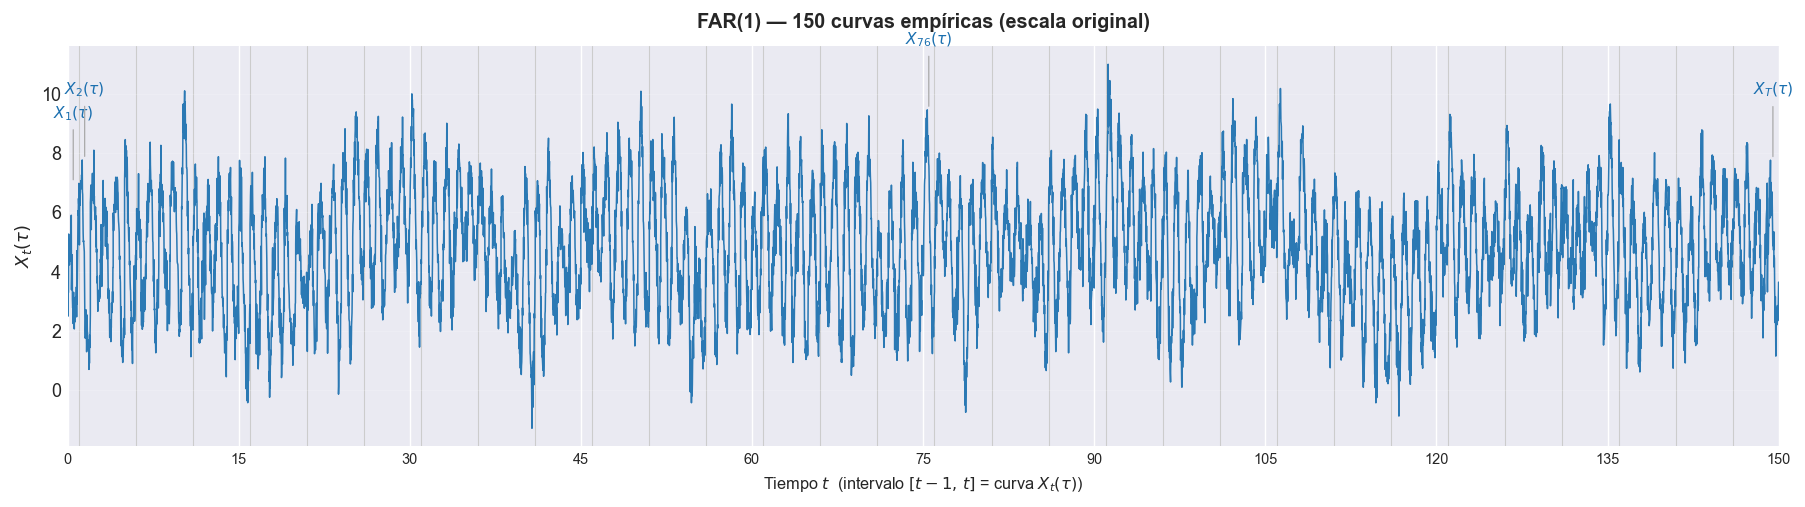

In [6]:
# ── Serie de tiempo funcional empírica (línea continua desplazada) ────────────
highlight_idx = [0, 1, T // 2, T - 1]

fig = plot_fts_empirical(
    X_raw, domain.grid,
    highlight_idx   = highlight_idx,
    title           = f"FAR(1) — {T} curvas empíricas (escala original)",
    separator_every = 5,
    save_path       = str(PATHS["out_report"] / "01_fts_empirica_raw.png"),
)
plt.show()

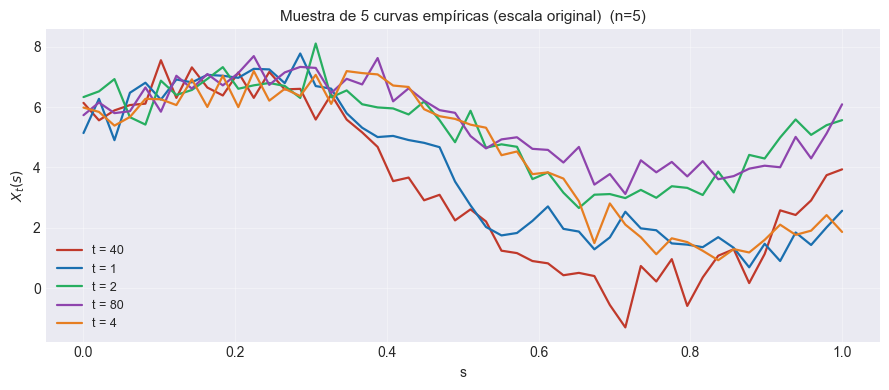

In [7]:
# ── Muestra de curvas empíricas (5 índices fijos) ─────────────────────────────
fig = plot_empirical_sample(
    X_raw, domain.grid,
    sample_idx = [40, 1, 2, 80, 4],
    title      = "Muestra de 5 curvas empíricas (escala original)",
    save_path  = str(PATHS["out_report"] / "02_muestra_empirica_raw.png"),
)
plt.show()

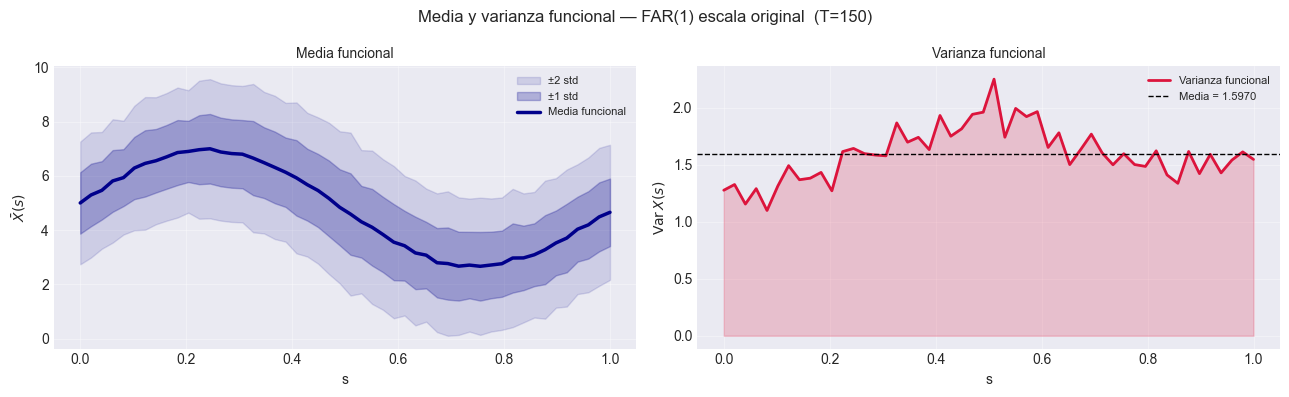

In [8]:
# ── Media y varianza funcional (panel combinado) ──────────────────────────────
fig = plot_mean_and_variance(
    X_raw, domain.grid,
    show_std1 = True,
    show_std2 = True,
    title     = "Media y varianza funcional — FAR(1) escala original",
    save_path = str(PATHS["out_report"] / "03_media_varianza_raw.png"),
)
plt.show()

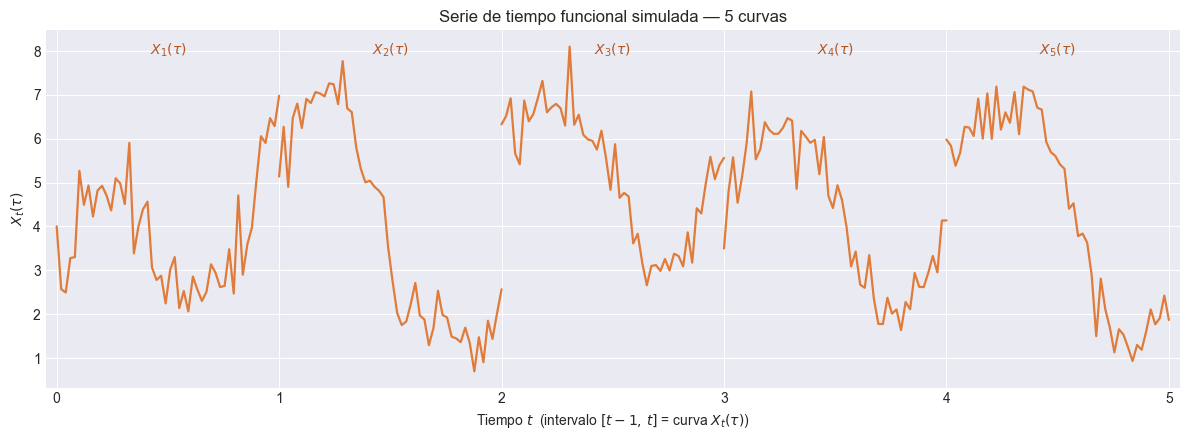

In [9]:
# ── 5 curvas como serie de tiempo (indexadas en t) — presentación ────────────
import numpy as np, matplotlib.pyplot as plt

n_dias = 5
X   = X_raw                                    # serie simulada (T, G); el alias 'X' también sirve
g   = np.asarray(domain.grid, dtype=float)
g01 = (g - g.min()) / (g.max() - g.min())      # dominio intra-curva normalizado a [0,1]

fig, ax = plt.subplots(figsize=(12, 4.5))
for i in range(n_dias):
    ax.plot(i + g01, X[i], color="#e07b39", lw=1.6)   # curva i ocupa el intervalo [i, i+1] en t

for i in range(n_dias + 1):                             # separadores
    ax.axvline(i, color="0.75", lw=0.8, zorder=0)
for i in range(n_dias):                                 # etiqueta por curva
    ax.text(i + 0.5, 0.97, f"$X_{{{i+1}}}(\\tau)$",
            transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=10, color="#b5561f")

ax.set_xlabel(r"Tiempo $t$  (intervalo $[t-1,\,t]$ = curva $X_t(\tau)$)")
ax.set_ylabel(r"$X_t(\tau)$")
ax.set_title("Serie de tiempo funcional simulada — 5 curvas")
ax.set_xticks(range(n_dias + 1))
ax.margins(x=0.01)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "pres_5_series_t_sim.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.3 Persistencia de datos crudos


In [10]:
X = X_raw   # alias para el resto del notebook (representación funcional sobre crudos)

# ── Guardar datos crudos ──────────────────────────────────────────────────
np.savetxt(PATHS["raw"] / "datos_raw.csv", X_raw, delimiter=",")
print(f"[raw] datos crudos {X_raw.shape} → {PATHS['raw']}")

# ── Guardar curvas y grilla en functional (los usa el notebook 02_03) ─────
np.save(PATHS["functional"] / "X_curves.npy",   X_raw)
np.save(PATHS["functional"] / "domain_grid.npy", domain.grid)
print(f"[functional] X_curves.npy     {X_raw.shape}  → {PATHS['functional']}")
print(f"[functional] domain_grid.npy  {domain.grid.shape}  → {PATHS['functional']}")


[raw] datos crudos (150, 50) → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\modelo_experimento_1_1
[functional] X_curves.npy     (150, 50)  → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\modelo_experimento_1_1
[functional] domain_grid.npy  (50,)  → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\modelo_experimento_1_1


## 2.4 Partición temporal de entrenamiento y prueba (§2.2.3.1)

La partición respeta el orden de la serie: todo objeto **estimado a partir de
los datos** (selección GCV de la base, FPCA, estandarizador) se ajusta
exclusivamente con el bloque inicial de entrenamiento $\{1,\dots,T_0\}$ y se
aplica al bloque de prueba $\{T_0+1,\dots,T\}$ mediante `transform`. El bloque
de prueba queda reservado para la evaluación fuera de muestra.

In [11]:
# ── Partición temporal (holdout) — §2.2.3.1 ─────────────────────────────────
PROP_TRAIN = 0.80                          # proporción del bloque de entrenamiento
T0 = int(np.floor(PROP_TRAIN * T))         # nº de curvas de entrenamiento

assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train = np.arange(0, T0)               # t = 1 … T0      (0-based)
idx_test  = np.arange(T0, T)               # t = T0+1 … T
X_train, X_test = X[idx_train], X[idx_test]

print("Partición temporal (holdout):")
print(f"  entrenamiento : t ∈ [1, {T0}]      →  {X_train.shape}")
print(f"  prueba        : t ∈ [{T0+1}, {T}]  →  {X_test.shape}")
print(f"  proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

Partición temporal (holdout):
  entrenamiento : t ∈ [1, 120]      →  (120, 50)
  prueba        : t ∈ [121, 150]  →  (30, 50)
  proporción    : 80.0% / 20.0%


# 3. Representación funcional B-spline

In [12]:
# SELECCIÓN DE PARÁMETROS PARA EVALUAR LA REPRESENTACIÓN FUNCIONAL (n_basis, order)
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # [HOLDOUT] rango acotado por T0
ORDER_RANGE   = range(2, 5)
selection_records = []

for order_bs in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < order_bs:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=order_bs)
            TH_tmp = fr_tmp.fit_transform(X_train, domain.grid)   # [HOLDOUT] solo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]                            # puntos por curva
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)      # SSE_i(K)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            vr     = 1.0 - sse_c.sum() / ss_tot                  # VE(K)
            rmse_c = np.sqrt(sse_c / L_i)                        # e_i(K)
            df_k   = nb                                          # df(K) = n_basis
            gcv_c  = (L_i * sse_c / (L_i - df_k) ** 2            # GCV_i(K)
                      if L_i > df_k else np.full_like(sse_c, np.nan))

            selection_records.append({
                "n_basis": nb, "order": order_bs, "var_retained": vr,
                "rmse_mean": rmse_c.mean(), "rmse_max": rmse_c.max(),
                "gcv_mean": float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={order_bs}: {e}")

sel_df = pd.DataFrame(selection_records)

# ── Criterio: mínimo de GCV promedio sobre las curvas ─────────────────────
sel_valid = sel_df.dropna(subset=["gcv_mean"])
best_row  = sel_valid.loc[sel_valid["gcv_mean"].idxmin()]
nb_best   = int(best_row["n_basis"])
ord_best  = int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"],     cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn")
    .background_gradient(subset=["rmse_mean"],    cmap="YlOrRd_r"))

print(f"\nSelección por GCV mínimo: n_basis={nb_best}, order={ord_best}, "
      f"GCV={best_row['gcv_mean']:.6f}")
print(f"Verificación descriptiva: var_retained={best_row['var_retained']:.4%}, "
      f"rmse_mean={best_row['rmse_mean']:.6f}, rmse_max={best_row['rmse_max']:.6f}")


,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,5.9109%,1.225894,1.880255,1.723258
1,3,2,23.3082%,1.106316,1.820292,1.465031
2,4,2,77.9212%,0.604824,0.930431,0.440305
3,5,2,83.3174%,0.526663,0.672634,0.347643
4,6,2,85.2063%,0.496423,0.631297,0.322452
5,7,2,86.1116%,0.481112,0.624165,0.316963
6,8,2,86.7548%,0.469933,0.610665,0.316850
7,9,2,87.0090%,0.465160,0.590036,0.326112
8,10,2,87.4082%,0.457818,0.590633,0.332094
9,11,2,87.6661%,0.453091,0.586637,0.342188



Selección por GCV mínimo: n_basis=7, order=4, GCV=0.308786
Verificación descriptiva: var_retained=86.4699%, rmse_mean=0.474921, rmse_max=0.591649


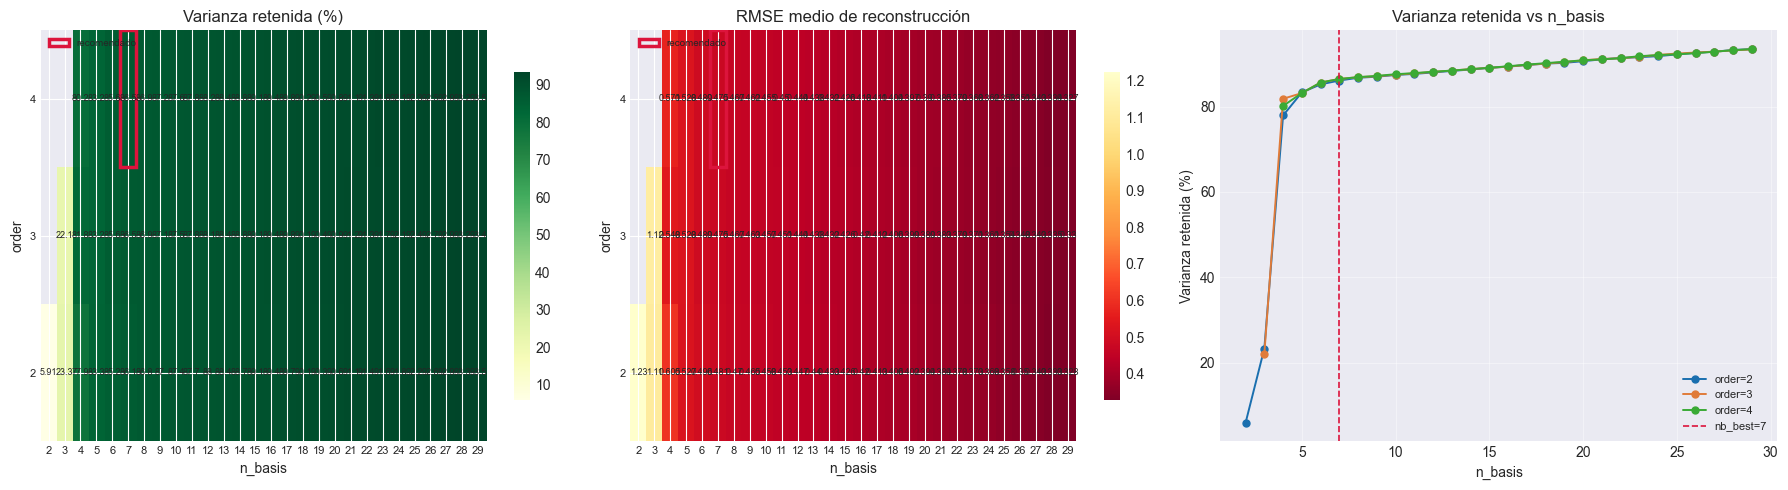

In [13]:
# ── Heatmaps + curva de varianza retenida ────────────────────────────────────
fig = plot_seleccion_basis(
    sel_df, nb_best, ord_best,
    save_path=str(PATHS["out_report"] / "08_seleccion_basis.png"),
)
plt.show()


## 3.1 Ajuste y visualización de la representación funcional

THETA shape: (150, 20)  (train=120, test=30)


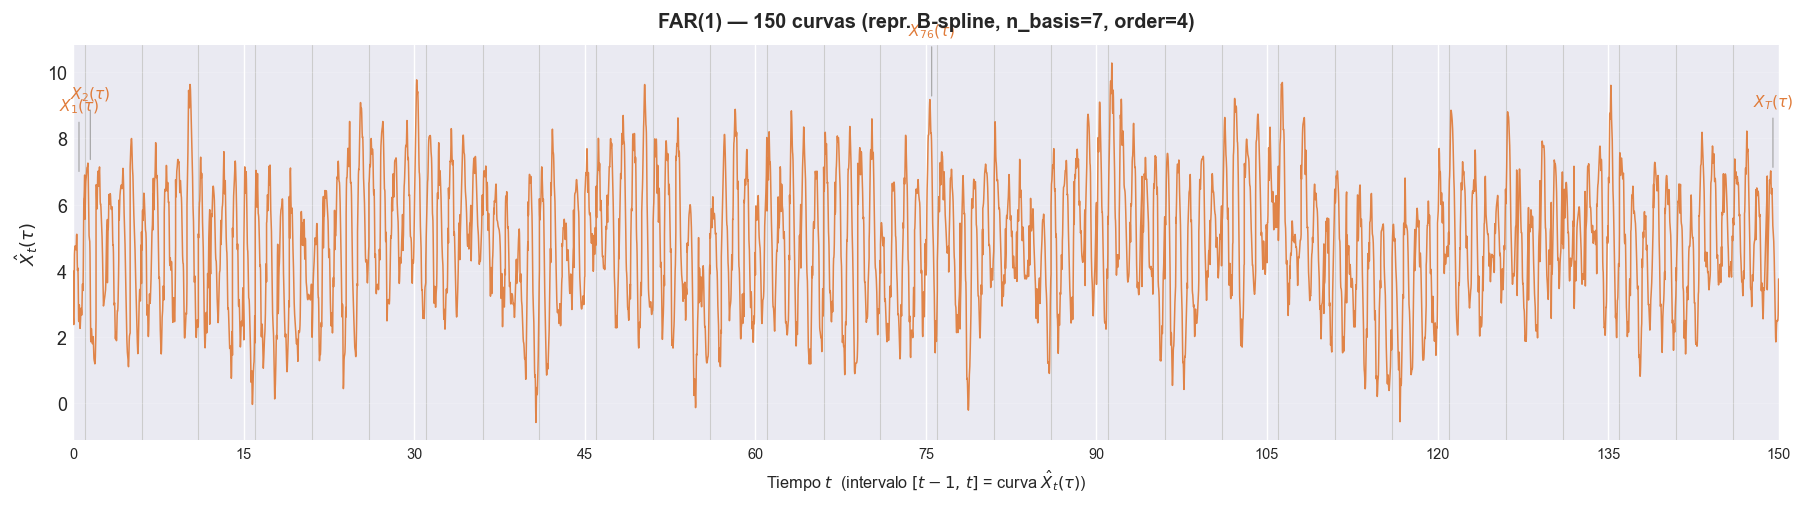

[functional] functional_representation.pkl  → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\modelo_experimento_1_1
[functional] fr_config.json                 → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\modelo_experimento_1_1


In [14]:
# CONSTANTES ELEGIDAS PARA LA REPRESENTACIÓN FUNCIONAL
# fr = FunctionalRepresentation(method="bspline", n_basis=nb_best, order=ord_best)
fr = FunctionalRepresentation(method="bspline", n_basis=20, order=3)


# [HOLDOUT] Ajuste SOLO con entrenamiento; proyección de toda la serie.
# Para B-splines la base depende únicamente de la grilla, pero se mantiene la
# disciplina fit/transform para que el patrón sea válido con cualquier método.
fr.fit(X_train, domain.grid)
THETA       = fr.transform(X, domain.grid)            # (T, K)  serie completa
THETA_train = THETA[idx_train]                        # (T0, K)
print(f"THETA shape: {THETA.shape}  (train={THETA_train.shape[0]}, test={T - T0})")

# ── Serie de tiempo funcional con representación B-spline ────────────────────
fig = plot_fts_functional(
    X, domain.grid,
    fr              = fr,
    highlight_idx   = highlight_idx,
    title           = f"FAR(1) — {T} curvas (repr. B-spline, n_basis={nb_best}, order={ord_best})",
    separator_every = 5,
    save_path       = str(PATHS["out_report"] / "09_fts_funcional_bspline.png"),
)
plt.show()

# ── Serializar FunctionalRepresentation (la usa el notebook 02_03) ───────────
fr_pkl_path = PATHS["functional"] / "functional_representation.pkl"
with open(fr_pkl_path, "wb") as _f:
    pickle.dump(fr, _f, protocol=pickle.HIGHEST_PROTOCOL)

# Config legible para referencia
fr_config = {
    "method":   fr.method if hasattr(fr, "method") else "bspline",
    "n_basis":  int(THETA.shape[1]),
    "order":    getattr(fr, "order", None),
    "T":        int(THETA.shape[0]),
    "K":        int(THETA.shape[1]),
    "T0":         int(T0),
    "prop_train": float(PROP_TRAIN),
    "ajustado_en": "train",
}
with open(PATHS["functional"] / "fr_config.json", "w", encoding="utf-8") as _f:
    json.dump(fr_config, _f, indent=2, ensure_ascii=False)

print(f"[functional] functional_representation.pkl  → {PATHS['functional']}")
print(f"[functional] fr_config.json                 → {PATHS['functional']}")


## 3.2 Pasar la base selecionada a FPCA analizar cuantos componentes me quedare

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,8.6730e-01,55.8942%,55.8942%,+0.690
1,2,3.0752e-01,19.8184%,75.7127%,+0.111
2,3,1.9217e-01,12.3849%,88.0975%,+0.019
3,4,7.5614e-02,4.8730%,92.9706%,+0.113
4,5,2.6645e-02,1.7172%,94.6878%,-0.048
5,6,1.2382e-02,0.7980%,95.4858%,-0.114
6,7,7.8697e-03,0.5072%,95.9930%,+0.093
7,8,7.6823e-03,0.4951%,96.4881%,+0.134
8,9,7.0175e-03,0.4522%,96.9403%,-0.108
9,10,6.3662e-03,0.4103%,97.3506%,-0.129



K B-spline disponibles : 20
SUGERENCIA (var ≥ 99%) : M_SUGGERIDO = 15   ← solo referencia; fija M_FPCA en la celda 3.4


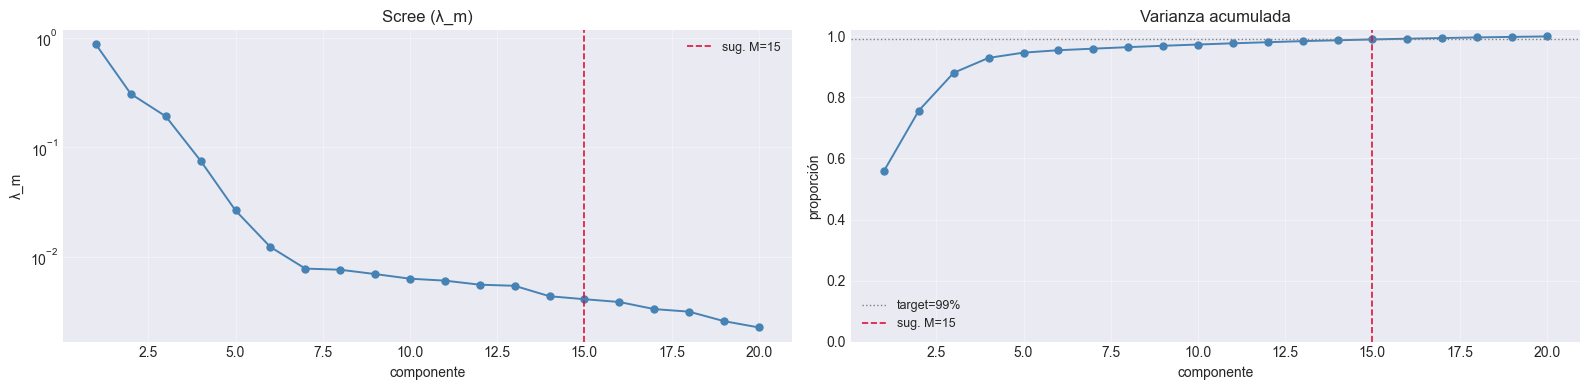

In [15]:
# Base B-spline NO ortonormal ⇒ Gram W = <φ_j,φ_k>_{L²} ≠ I. La FPCA correcta
# diagonaliza en métrica L²:  (W^{1/2} S_θ W^{1/2}) u = λ u,  ‖ψ_m‖_{L²}=1.
# ----------------------------------------------------------------------------
K = THETA.shape[1]

# ── Base en grilla + verificación de linealidad de reconstruct ───────────────
Phi = fr.reconstruct(np.eye(K)).T                        # (G, K): columna k = φ_k en grilla
_lin_err = np.abs(fr.reconstruct(THETA) - THETA @ Phi.T).max()
assert _lin_err < 1e-8, (
    f"reconstruct no es el mapa lineal Θ·Φᵀ esperado (err={_lin_err:.2e})."
)

# ── Gram L² (cuadratura trapezoidal) ─────────────────────────────────────────
gpts = np.asarray(domain.grid, dtype=float)
w_quad = np.empty_like(gpts)
w_quad[1:-1] = (gpts[2:] - gpts[:-2]) / 2.0
w_quad[0]    = (gpts[1]  - gpts[0])  / 2.0
w_quad[-1]   = (gpts[-1] - gpts[-2]) / 2.0
W = Phi.T @ (w_quad[:, None] * Phi); W = 0.5 * (W + W.T)

# ── Covarianza de coeficientes y problema propio simetrizado en L² ───────────
# [HOLDOUT] media y covarianza estimadas SOLO con el bloque de entrenamiento
mu_theta      = THETA_train.mean(axis=0)
Theta_c_train = THETA_train - mu_theta
S_theta       = (Theta_c_train.T @ Theta_c_train) / (THETA_train.shape[0] - 1)
Theta_c       = THETA - mu_theta            # serie completa, centrada con media de train
evW, VW    = np.linalg.eigh(W); evW = np.clip(evW, 1e-12, None)
W_half     = VW @ np.diag(np.sqrt(evW))   @ VW.T
W_half_inv = VW @ np.diag(1 / np.sqrt(evW)) @ VW.T
M_sym = W_half @ S_theta @ W_half; M_sym = 0.5 * (M_sym + M_sym.T)
evals, U = np.linalg.eigh(M_sym)
ord_desc = np.argsort(evals)[::-1]   # [FIX] renombrado: 'order' sombreaba el order B-spline
evals = np.clip(evals[ord_desc], 0.0, None); U = U[:, ord_desc]
B_full = W_half_inv @ U                                  # (K, K) coef. autofunciones (b_mᵀ W b_m = 1)
var_ratio = evals / evals.sum(); var_cum = np.cumsum(var_ratio)

# ── Diagnóstico DINÁMICO: AR(1) propio de cada componente (≠ varianza) ───────
# Varianza = representación; AR(1) = dinámica. Una FPC de var. baja puede tener
# AR fuerte (útil para pronóstico) y una de var. alta puede ser ruido temporal.
# [HOLDOUT] el diagnóstico dinámico se calcula SOLO sobre entrenamiento
SCORES_full = Theta_c_train @ (W @ B_full)               # (T0, K) scores de TODAS las componentes
s0, s1 = SCORES_full[:-1], SCORES_full[1:]
ar1_own = (s1 * s0).sum(0) / np.clip((s0 * s0).sum(0), 1e-12, None)   # pendiente AR(1) por comp.

# ── Sugerencia automática (SOLO referencia; no vincula nada) ─────────────────
VAR_TARGET  = 0.99
M_SUGGERIDO = int(np.clip(np.searchsorted(var_cum, VAR_TARGET) + 1, 1, K))

# ── Tabla ─────────────────────────────────────────────────────────────────────
fpca_tbl = pd.DataFrame({
    "componente": np.arange(1, K + 1),
    "autovalor":  evals,
    "var_ratio":  var_ratio,
    "var_acum":   var_cum,
    "ar1_propio": ar1_own,
})
display(fpca_tbl.head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}", "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"}
).background_gradient(subset=["var_ratio"], cmap="YlGn")
 .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))
print(f"\nK B-spline disponibles : {K}")
print(f"SUGERENCIA (var ≥ {VAR_TARGET:.0%}) : M_SUGGERIDO = {M_SUGGERIDO}   "
      f"← solo referencia; fija M_FPCA en la celda 3.4")

# ── Scree + varianza acumulada ────────────────────────────────────────────────
fig = plot_fpca_scree(
    evals, var_cum, M_SUGGERIDO,
    var_target=VAR_TARGET,
    save_path=str(PATHS["out_report"] / "10_fpca_scree.png"),
)
plt.show()

## 3.3 Obtener el FPCA basado en la selecion

[sanidad] max|<ψ_i,ψ_j> - I| : 2.53e-15   (≈ 0)
max|media ξ| (train)         : 1.21e-16   (≈ 0)
max|diag(Γ0) - λ|            : 5.55e-16   (≈ 0)
max|correlación fuera diag.| : 1.32e-15   (≈ 0 ⇒ sin correlación contemporánea)
[test] max|media ξ|          : 0.286
[test] var ξ / λ (train)     : [0.331 0.943 0.997 0.891 1.227]


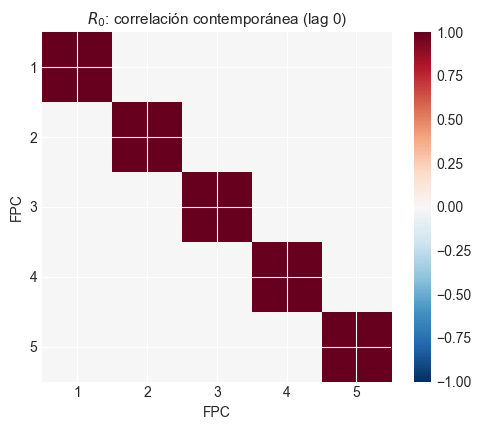


SCORES shape : (150, 5)   (T=150, M=5)


In [16]:
M_FPCA = 5    # ← nº de componentes FPCA a retener (lo fijas TÚ)

# ── Validación (no avanza hasta que elijas) ──────────────────────────────────
assert M_FPCA is not None, "Define M_FPCA (entero) en esta celda antes de continuar."
assert isinstance(M_FPCA, (int, np.integer)) and 1 <= M_FPCA <= K, (
    f"M_FPCA debe ser entero en [1, {K}]. Recibido: {M_FPCA!r}"
)
M_fpca = int(M_FPCA)                                     # alias en minúscula para el resto del notebook

# ── Construcción con el M elegido ────────────────────────────────────────────
B        = B_full[:, :M_fpca]                            # (K, M)
Psi_grid = Phi @ B                                       # (G, M) autofunciones (‖ψ_m‖_{L²}=1)
mu_grid  = Phi @ mu_theta                                # (G,)
# [HOLDOUT] scores de TODA la serie proyectados sobre la base de entrenamiento
SCORES       = Theta_c @ (W @ B)                         # (T, M) scores ξ
SCORES_train = SCORES[idx_train]
SCORES_test  = SCORES[idx_test]

# ── Sanidad de construcción: autofunciones ortonormales en L² (Gram ≈ I) ─────
gram_psi = Psi_grid.T @ (w_quad[:, None] * Psi_grid)
print(f"[sanidad] max|<ψ_i,ψ_j> - I| : {np.abs(gram_psi - np.eye(M_fpca)).max():.2e}   (≈ 0)")

# EVALUACIÓN DE CORRELACIÓN  (lag 0)
# [HOLDOUT] las propiedades FPCA (media 0, var = λ, no correlación) son
# consecuencia del ajuste y se verifican en ENTRENAMIENTO; en prueba su
# desviación es diagnóstica, no un error.
Gamma0 = np.atleast_2d(np.cov(SCORES_train, rowvar=False, ddof=1))   # covarianza lag 0
R0     = np.atleast_2d(np.corrcoef(SCORES_train, rowvar=False))      # correlación lag 0
off_R0 = np.abs(R0 - np.eye(M_fpca))

print(f"max|media ξ| (train)         : {np.abs(SCORES_train.mean(0)).max():.2e}   (≈ 0)")
print(f"max|diag(Γ0) - λ|            : {np.abs(np.diag(Gamma0) - evals[:M_fpca]).max():.2e}   (≈ 0)")
print(f"max|correlación fuera diag.| : {off_R0.max():.2e}   (≈ 0 ⇒ sin correlación contemporánea)")

# ── Chequeo fuera de muestra: deriva entre bloques (estacionariedad §2.2.1) ──
print(f"[test] max|media ξ|          : {np.abs(SCORES_test.mean(0)).max():.3f}")
print(f"[test] var ξ / λ (train)     : "
      f"{np.array2string(SCORES_test.var(0, ddof=1) / evals[:M_fpca], precision=3)}")

if M_fpca >= 2:
    fig = plot_fpca_correlacion_lag0(
        R0,
        save_path=str(PATHS["out_report"] / "11_fpca_correlacion_lag0.png"),
    )
    plt.show()

# ── Empaquetado FPCA + operador de reconstrucción (inversa de FPCA) ──────────
def reconstruct_from_scores(S_hat):
    """X̂(t) = μ(t) + Σ_m ξ_m ψ_m(t)."""
    S_hat = np.atleast_2d(np.asarray(S_hat, dtype=float))
    return mu_grid[None, :] + S_hat @ Psi_grid.T

FPCA = {
    "M": M_fpca, "eigvals": evals[:M_fpca], "mean_grid": mu_grid,
    "eigfun_grid": Psi_grid, "coef_eigfun": B, "gram": W,
    "reconstruct": reconstruct_from_scores,
}

# ── Persistencia de datos · representación funcional + FPCA → data/.../functional ──
np.savetxt(PATHS["functional"] / "theta.csv",               THETA,    delimiter=",")
np.savetxt(PATHS["functional"] / "basis_phi.csv",           Phi,      delimiter=",")
np.savetxt(PATHS["functional"] / "grid.csv",                gpts,     delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_scores.csv",         SCORES,   delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_eigenfunctions.csv", Psi_grid, delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_mean.csv",           mu_grid,  delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_gram_W.csv",      W,        delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_coef_B.csv",      B,        delimiter=",")
np.savetxt(PATHS["functional"] / "fpca_mu_theta.csv",    mu_theta, delimiter=",")
with open(PATHS["functional"] / "fpca_meta.json", "w", encoding="utf-8") as _f:
    json.dump({"M": int(M_fpca), "K": int(THETA.shape[1]),
               "eigvals": FPCA["eigvals"].tolist(),
               "var_explained": float(var_cum[M_fpca - 1]), "var_target": VAR_TARGET},
              _f, indent=2, ensure_ascii=False)

print(f"\nSCORES shape : {SCORES.shape}   (T={SCORES.shape[0]}, M={M_fpca})")

# 4. Construcción de datasets AR(p) sobre scores de FPCA (ecuación-por-ecuación)

## 4.0 Estandarización de scores ξ  **[FIX — punto de entrada al modelo]**

Los scores FPCA tienen varianza λₘ (heterogénea entre componentes:
λ₁ ≫ λ_M). Se estandarizan por columna (z-score, ddof=0) **antes** de
construir los datasets AR(p): respuesta y covariables entran al PSBP en
escala estandarizada. El estandarizador se persiste para que `02_03`
des-estandarice las predicciones antes de reconstruir curvas.

Nota: las correlaciones de rezagos (§4.1) son invariantes a esta
transformación lineal; se calculan sobre `SCORES_STD` por consistencia.

Método: zscore_column
Features: 5
  Media:     min=-0.0000, max=0.0000
  Std:       min=0.1626, max=0.9274
SCORES_STD : shape=(150, 5)  (train=120, test=30)
  [train] max|media| = 2.31e-17  (≈ 0 por construcción)
  [train] max|std-1| = 3.33e-16  (≈ 0 por construcción)
  [test]  media      = [-0.221  0.517 -0.068 -0.167 -0.037]
  [test]  std        = [0.568 0.959 0.986 0.932 1.094]
  std train por componente (=√λ_m): [0.927 0.552 0.437 0.274 0.163]
✓ Standardizer guardado en: C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\modelo_experimento_1_1\scores_standardizer
[functional] fpca_scores_std.csv (150, 5) → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\modelo_experimento_1_1


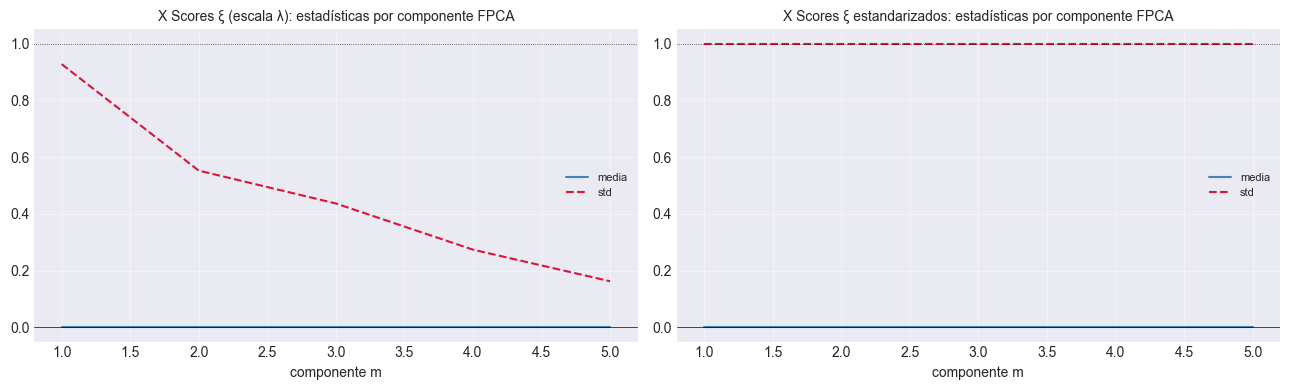

In [17]:
scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
scores_standardizer.fit(SCORES_train)                 # [HOLDOUT] fit SOLO en train
SCORES_STD       = scores_standardizer.transform(SCORES)   # aplicado a toda la serie
SCORES_STD_train = SCORES_STD[idx_train]
SCORES_STD_test  = SCORES_STD[idx_test]

print(scores_standardizer.summary())
print(f"SCORES_STD : shape={SCORES_STD.shape}  (train={T0}, test={T - T0})")
print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}  (≈ 0 por construcción)")
print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}  (≈ 0 por construcción)")
print(f"  [test]  media      = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
print(f"  [test]  std        = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")
print(f"  std train por componente (=√λ_m): "
      f"{np.array2string(SCORES_train.std(axis=0), precision=3)}")

# ── Persistencia ─────────────────────────────────────────────────────────────
scores_standardizer.save(PATHS["functional"] / "scores_standardizer")
np.savetxt(PATHS["functional"] / "fpca_scores_std.csv", SCORES_STD, delimiter=",")
print(f"[functional] fpca_scores_std.csv {SCORES_STD.shape} → {PATHS['functional']}")

# ── Diagnóstico visual (media/std por componente, antes y después) ───────────
fig = plot_diagnostico_estandarizacion(
    SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
    labels=("Scores ξ (escala λ)", "Scores ξ estandarizados"),
    title="estadísticas por componente FPCA",
    save_path=str(PATHS["out_report"] / "04_diagnostico_estandarizacion_scores.png"),
)
fig.axes[0].set_xlabel("componente m"); fig.axes[1].set_xlabel("componente m")
plt.show()


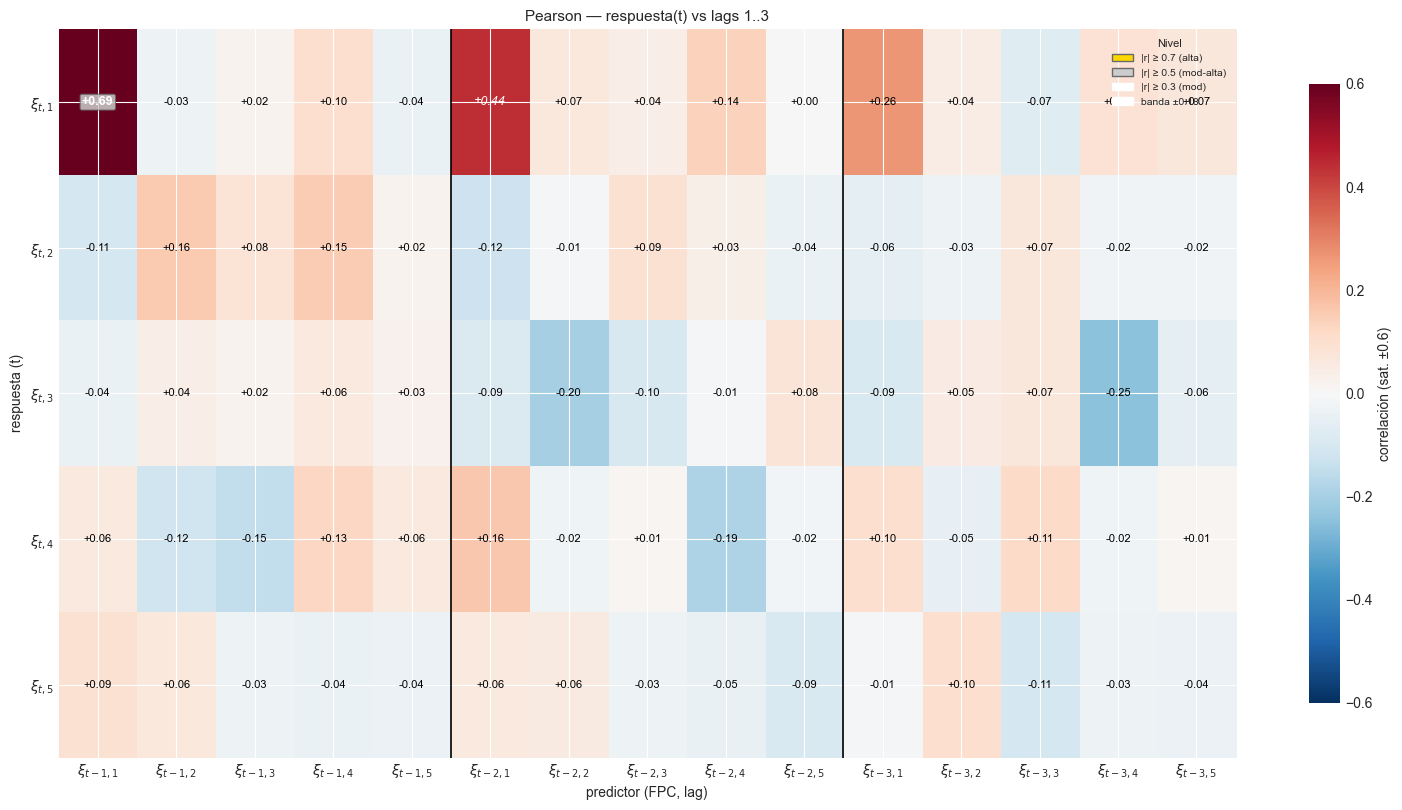

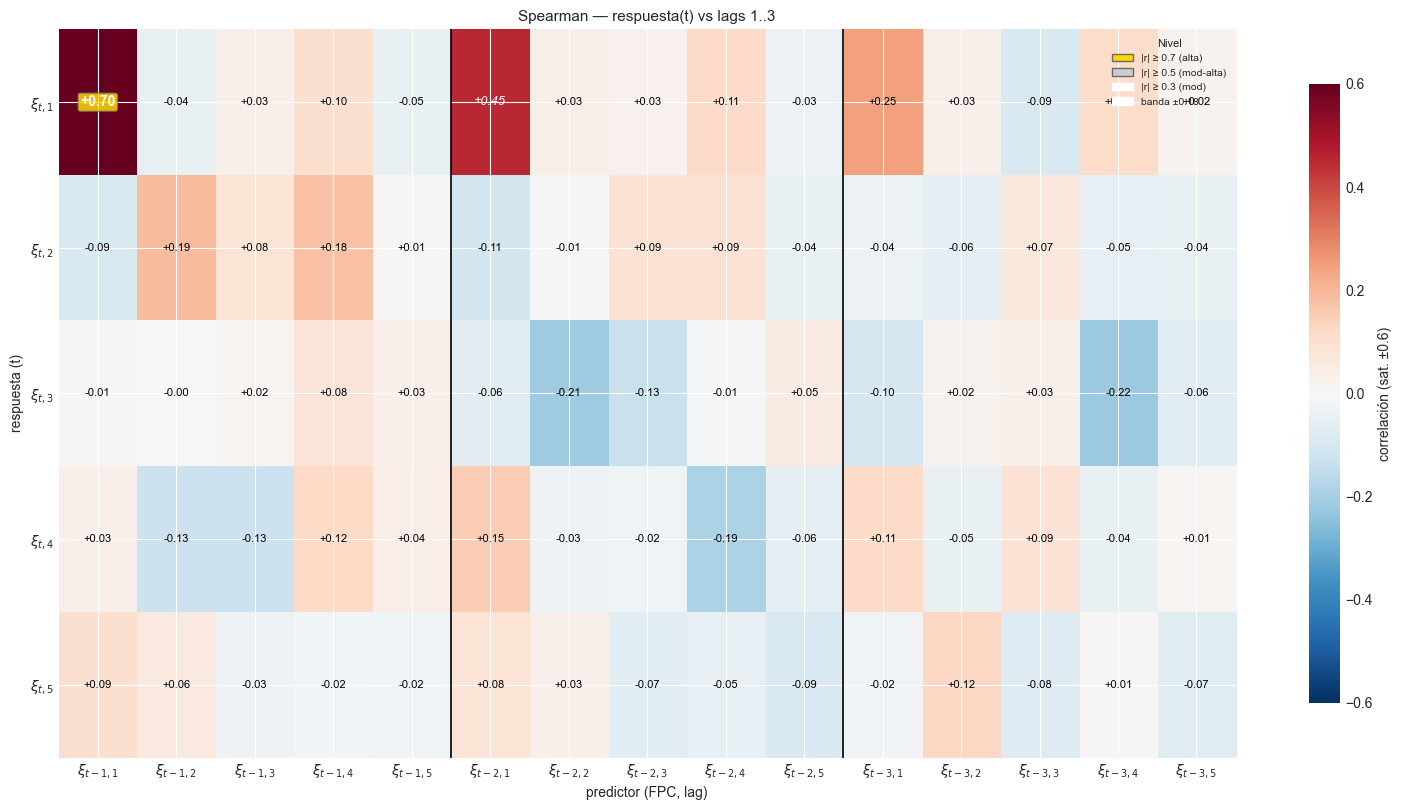

In [18]:
# [HOLDOUT] la elección de rezagos es una decisión de modelado: solo train
T_theta = SCORES_STD_train.shape[0]
K_total = SCORES_STD_train.shape[1]                          # nº de FPC disponibles (M)

# Lags de Diagnostico
N_LAGS_MAX = 3
N_LAGS_MAX = int(np.clip(N_LAGS_MAX, 1, T_theta - 2))

def _spearman_block(Y, X):
    """Spearman columna-a-columna vía rangos (pandas; sin scipy)."""
    Yr = pd.DataFrame(Y).rank().to_numpy()
    Xr = pd.DataFrame(X).rank().to_numpy()
    Yc = Yr - Yr.mean(0); Xc = Xr - Xr.mean(0)
    return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

# ── Matrices de correlación: respuesta (t) × predictor (FPC j, lag ℓ) ────────
n_cov = K_total * N_LAGS_MAX
corr_pearson  = np.zeros((K_total, n_cov))
corr_spearman = np.zeros((K_total, n_cov))
col_labels = []
y_block = SCORES_STD_train[N_LAGS_MAX:, :]                         # respuesta en t (alineada)

for lag in range(1, N_LAGS_MAX + 1):
    x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]   # predictores en t-lag
    sp = _spearman_block(y_block, x_block)
    for j in range(K_total):
        c = (lag - 1) * K_total + j
        for k in range(K_total):
            corr_pearson[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
        corr_spearman[:, c] = sp[:, j]
        col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
band  = 1.96 / np.sqrt(len(y_block))                     # banda de significancia (referencia)
VCLIP = 0.6

# ── Heatmaps de correlación ───────────────────────────────────────────────────
fig = plot_rezagos_heatmap(
    corr_pearson, col_labels, row_labels,
    title=f"Pearson — respuesta(t) vs lags 1..{N_LAGS_MAX}",
    n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=VCLIP,
    save_path=str(PATHS["out_report"] / "12a_rezagos_pearson.png"),
)
plt.show()

fig = plot_rezagos_heatmap(
    corr_spearman, col_labels, row_labels,
    title=f"Spearman — respuesta(t) vs lags 1..{N_LAGS_MAX}",
    n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=VCLIP,
    save_path=str(PATHS["out_report"] / "12b_rezagos_spearman.png"),
)
plt.show()


## 4.1 Selecion de lags y DATSET final 

In [19]:
N_LAGS  = 3
K_total = SCORES_STD.shape[1]        # nº de FPC disponibles (M)
COMPONENT_IDX = list(range(K_total))

# [HOLDOUT] tamaños efectivos por bloque
n_train_eff = T0 - N_LAGS            # respuestas en t = N_LAGS+1 … T0
n_test_eff  = T - T0                 # respuestas en t = T0+1 … T (rezagos desde train)

assert T0 > N_LAGS, f"T0={T0} debe superar N_LAGS={N_LAGS}."

print(f"K_total disponibles : {K_total}  (índices 0 … {K_total - 1})")
print(f"T / T0              : {T} / {T0}")
print(f"N_LAGS              : {N_LAGS}")
print(f"n_train_eff         : {n_train_eff}")
print(f"n_test_eff          : {n_test_eff}")

K_total disponibles : 5  (índices 0 … 4)
T / T0              : 150 / 120
N_LAGS              : 3
n_train_eff         : 117
n_test_eff          : 30


In [20]:
# ── Validación ───────────────────────────────────────────────────────────────
assert len(COMPONENT_IDX) > 0, "COMPONENT_IDX no puede estar vacío."
assert len(COMPONENT_IDX) == len(set(COMPONENT_IDX)), "COMPONENT_IDX tiene índices repetidos."
assert all(0 <= i < K_total for i in COMPONENT_IDX), (
    f"Todos los índices deben estar en [0, {K_total - 1}]. Recibido: {COMPONENT_IDX}"
)

n_components = len(COMPONENT_IDX)

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"K_total disponibles : {K_total}")
print(f"Componentes usados  : {n_components}  →  índices {COMPONENT_IDX}")
print(f"Orden AR (N_LAGS)   : {N_LAGS}")
print()
print(f"  {'k_modelo':>8}  {'idx_THETA':>10}  {'nombre_resp':>14}")
print(f"  {'─'*8}  {'─'*10}  {'─'*14}")
for k_model, idx in enumerate(COMPONENT_IDX):
    print(f"  {k_model:>8}  {idx:>10}  {'fpc_' + str(idx + 1):>14}")

K_total disponibles : 5
Componentes usados  : 5  →  índices [0, 1, 2, 3, 4]
Orden AR (N_LAGS)   : 3

  k_modelo   idx_THETA     nombre_resp
  ────────  ──────────  ──────────────
         0           0           fpc_1
         1           1           fpc_2
         2           2           fpc_3
         3           3           fpc_4
         4           4           fpc_5


In [21]:
# ── Construcción de DataFrames AR(p): bloques de entrenamiento y prueba ──────
SCORES_sel = SCORES_STD[:, COMPONENT_IDX]   # (T, n_components) estandarizados

cov_names = [
    f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
    for lag in range(1, N_LAGS + 1)
    for j in range(n_components)
]

def _dataset_bloque(k: int, t_ini: int, t_fin: int) -> pd.DataFrame:
    """
    Filas con respuesta en t ∈ [t_ini, t_fin) y predictores en t-1 … t-N_LAGS.

    Los rezagos del primer origen de prueba provienen del final del bloque de
    entrenamiento: son observaciones pasadas disponibles en cada origen, de
    modo que su uso es el condicionamiento que prescribe §2.2.3.1 (predicción
    a horizonte h=1 con la historia observada), no fuga de información.
    """
    t_idx  = np.arange(t_ini, t_fin)
    y_col  = SCORES_sel[t_idx, k]
    X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
    return pd.DataFrame(np.column_stack([y_col, X_cols]),
                        columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

dfs_train, dfs_test = {}, {}
for k in range(n_components):
    dfs_train[k] = _dataset_bloque(k, N_LAGS, T0)     # (T0 - N_LAGS) filas
    dfs_test[k]  = _dataset_bloque(k, T0,     T)      # (T - T0) filas

# alias de compatibilidad: el resto del flujo (hiperparámetros) itera sobre dfs
dfs = dfs_train

manifest = {
    "scores_scale":  "standardized_zscore_ddof0",
    "n_components":  n_components,
    "n_lags":        int(N_LAGS),
    "component_idx": [int(i) for i in COMPONENT_IDX],
    "cov_names":     cov_names,
    # ── Partición temporal (§2.2.3.1) ──
    "T":             int(T),
    "T0":            int(T0),
    "prop_train":    float(PROP_TRAIN),
    "n_train_eff":   int(n_train_eff),
    "n_test_eff":    int(n_test_eff),
    "ajuste_en":     "train",   # GCV, base B-spline, FPCA y estandarizador
    "datasets":      {"train": {}, "test": {}},
}

for k in range(n_components):
    resp = f"fpc_{COMPONENT_IDX[k] + 1}"
    for bloque, tabla in (("train", dfs_train[k]), ("test", dfs_test[k])):
        fname = f"dataset_{resp}_{bloque}.csv"
        tabla.to_csv(PATHS["functional"] / fname, index=False)
        manifest["datasets"][bloque][fname] = {"response": resp,
                                               "shape": list(tabla.shape)}
        print(f"  guardado {fname}  resp='{resp}'  shape={tabla.shape}")

with open(PATHS["functional"] / "datasets_manifest.json", "w", encoding="utf-8") as _f:
    json.dump(manifest, _f, indent=2, ensure_ascii=False)
print(f"[functional] {2*n_components} datasets + datasets_manifest.json → {PATHS['functional']}")

  guardado dataset_fpc_1_train.csv  resp='fpc_1'  shape=(117, 16)
  guardado dataset_fpc_1_test.csv  resp='fpc_1'  shape=(30, 16)
  guardado dataset_fpc_2_train.csv  resp='fpc_2'  shape=(117, 16)
  guardado dataset_fpc_2_test.csv  resp='fpc_2'  shape=(30, 16)
  guardado dataset_fpc_3_train.csv  resp='fpc_3'  shape=(117, 16)
  guardado dataset_fpc_3_test.csv  resp='fpc_3'  shape=(30, 16)
  guardado dataset_fpc_4_train.csv  resp='fpc_4'  shape=(117, 16)
  guardado dataset_fpc_4_test.csv  resp='fpc_4'  shape=(30, 16)
  guardado dataset_fpc_5_train.csv  resp='fpc_5'  shape=(117, 16)
  guardado dataset_fpc_5_test.csv  resp='fpc_5'  shape=(30, 16)
[functional] 10 datasets + datasets_manifest.json → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\modelo_experimento_1_1


# 5. Especificación de hiperparámetros y ajuste MCMC

In [22]:
MCMC_CONFIG = {"nsim": 2000, "burn": 500, "N": 20, "M": 50}
N_CHAINS    = 3
BURN        = int(MCMC_CONFIG["burn"])
print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS}  (réplicas que ejecutará MATLAB)")


MCMC_CONFIG : {'nsim': 2000, 'burn': 500, 'N': 20, 'M': 50}
N_CHAINS    : 3  (réplicas que ejecutará MATLAB)


In [23]:
# ════════════════════════════════════════════════════════════════════════════
# HIPERPARÁMETROS — priors heterogéneas por tipo de variable
# ════════════════════════════════════════════════════════════════════════════

# ── Escalares globales ────────────────────────────────────────────────────────
HP_GLOBAL = {
    "atau":  2.0,
    "btau":  0.5,
    "ag":    2.0,
    "bg":    0.5,
    "mumu":  0.0,
    "taumu": 1.0,
    "pwj":   0.5,
}

# ── Priors por tipo de variable ───────────────────────────────────────────────
#   Formato: "tipo": (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0,  0.0, 1.0),   # E[π] = 0.90
    "cross_lag": (1.0, 1.0,  0.0, 1.0),   # E[π] = 0.50
}

# ── Clasificador ──────────────────────────────────────────────────────────────
def _classify(name: str, k_model: int, component_idx: list) -> str:
    own_name = f"fpc_{component_idx[k_model] + 1}_lag1"
    if name == own_name:
        return "own_lag1"
    if "_lag" in name:
        return "cross_lag"
    return "cross_lag"   # fallback: cualquier variable no reconocida → débil

# ── Construcción automática de HYPERPARAMS_LIST ───────────────────────────────
HYPERPARAMS_LIST = []
for k in range(n_components):
    p = len(cov_names)
    apij    = np.empty(p); bpij    = np.empty(p)
    mupsij  = np.empty(p); taupsij = np.empty(p)

    for j, name in enumerate(cov_names):
        vtype              = _classify(name, k, COMPONENT_IDX)
        a, b, mu, tau      = HP_BY_TYPE[vtype]
        apij[j]    = a;    bpij[j]    = b
        mupsij[j]  = mu;   taupsij[j] = tau

    HYPERPARAMS_LIST.append({**HP_GLOBAL,
                              "apij": apij,     "bpij": bpij,
                              "mupsij": mupsij, "taupsij": taupsij})

# ── Tabla de resumen ──────────────────────────────────────────────────────────
_W = 70
print("═" * _W)
print(f"  HYPERPARAMS_LIST  —  {n_components} componentes × {p} variables")
print("═" * _W)
print(f"  Globales: atau={HP_GLOBAL['atau']} btau={HP_GLOBAL['btau']}  "
      f"ag={HP_GLOBAL['ag']} bg={HP_GLOBAL['bg']}  "
      f"mumu={HP_GLOBAL['mumu']} taumu={HP_GLOBAL['taumu']}  "
      f"pwj={HP_GLOBAL['pwj']}")
print()
for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"  Componente k={k+1}  (fpc_{COMPONENT_IDX[k]+1})")
    print(f"  {'Variable':<26} {'Tipo':<12} {'apij':>6} {'bpij':>6} "
          f"{'E[π]':>6} {'mupsij':>8} {'taupsij':>9}")
    print(f"  {'─'*26} {'─'*12} {'─'*6} {'─'*6} "
          f"{'─'*6} {'─'*8} {'─'*9}")
    for j, name in enumerate(cov_names):
        vtype = _classify(name, k, COMPONENT_IDX)
        a  = hp["apij"][j];    b  = hp["bpij"][j]
        mu = hp["mupsij"][j];  tau = hp["taupsij"][j]
        e_pi = a / (a + b)
        marker = "  ◄" if vtype == "own_lag1" else ""
        print(f"  {name:<26} {vtype:<12} {a:>6.1f} {b:>6.1f} "
              f"{e_pi:>6.3f} {mu:>8.1f} {tau:>9.1f}{marker}")
    print()

══════════════════════════════════════════════════════════════════════
  HYPERPARAMS_LIST  —  5 componentes × 15 variables
══════════════════════════════════════════════════════════════════════
  Globales: atau=2.0 btau=0.5  ag=2.0 bg=0.5  mumu=0.0 taumu=1.0  pwj=0.5

  Componente k=1  (fpc_1)
  Variable                   Tipo           apij   bpij   E[π]   mupsij   taupsij
  ────────────────────────── ──────────── ────── ────── ────── ──────── ─────────
  fpc_1_lag1                 own_lag1        9.0    1.0  0.900      0.0       1.0  ◄
  fpc_2_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_3_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_4_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_5_lag1                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_1_lag2                 cross_lag       1.0    1.0  0.500      0.0       1.0
  fpc_2_lag2                 cross_lag       1

In [24]:
# ── Guardar hiperparámetros del modelo en artefact ───────────────────────────
filepath_hyperparams = PATHS["out_artefact"] / "hyperparameters.json"

hp_artifact = {
    "global": HP_GLOBAL,
    "by_type": HP_BY_TYPE,
    "mcmc_config": MCMC_CONFIG,
    "n_iter": N_CHAINS,
    # [FIX] esquema real de semillas usado por psbp_fd_iteracion.m
    "seed_scheme": "SEED_BASE + tt*9973 + k*31",
    "seed_base": SEED,
    "scores_scale": "standardized_zscore_ddof0",
    # [HOLDOUT] partición temporal — MATLAB entrena SOLO con *_train.csv
    "partition": {
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                        for k in range(n_components)],
        "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                        for k in range(n_components)],
    },
    "hyperparams_list": []
}

for k in range(n_components):
    hp = HYPERPARAMS_LIST[k].copy()
    hp_artifact["hyperparams_list"].append({
        "component_k": k,
        "fpc_idx": int(COMPONENT_IDX[k] + 1),
        "hyperparams": {
            key: value.tolist() if isinstance(value, np.ndarray) else value
            for key, value in hp.items()
        }
    })

with open(filepath_hyperparams, "w", encoding="utf-8") as f:
    json.dump(hp_artifact, f, indent=2, ensure_ascii=False)

print(f"✓ Hiperparámetros guardados en: {filepath_hyperparams}")

✓ Hiperparámetros guardados en: C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\modelo_experimento_1_1\hyperparameters.json


# 6. Configuración de evaluación y líneas base (bloque de prueba)

Se persiste la configuración de evaluación (§2.2.3) que consumirá el flujo de
resultados, y se calculan **líneas base** sobre el bloque de prueba: el
predictor ingenuo de persistencia ($\hat\xi_t = \xi_{t-1}$) y la media
incondicional de entrenamiento ($\hat\xi_t = 0$ en escala estandarizada).
Ambas se evalúan a nivel de scores (RMSE) y a nivel de curva (MISE, RMSE
funcional), y constituyen el piso que todo modelo debe superar para justificar
su complejidad. No requieren MCMC, por lo que viven en este flujo.

In [25]:
# ── Configuración de evaluación (la consume el flujo de resultados) ──────────
eval_config = {
    "scheme":        "holdout_temporal",       # §2.2.3.1
    "T":             int(T),
    "T0":            int(T0),
    "prop_train":    float(PROP_TRAIN),
    "horizons":      [1],                      # h=1 vía dataset_test; h>1: simulación
    "n_lags":        int(N_LAGS),
    "metrics_scores": ["RMSE", "R2"],          # §2.2.3.2 sobre coeficientes
    "metrics_curvas": ["MISE", "RMSE_funcional"],
    "metrics_dist":   ["LPS", "CRPS", "cobertura_95", "PIT"],   # §2.2.3.3 (flujo 3)
    "scores_scale":  "standardized_zscore_ddof0",
}
with open(PATHS["out_artefact"] / "eval_config.json", "w", encoding="utf-8") as _f:
    json.dump(eval_config, _f, indent=2, ensure_ascii=False)
print(f"[out_artefact] eval_config.json → {PATHS['out_artefact']}")

# ── Líneas base sobre el bloque de prueba (h = 1) ────────────────────────────
# En escala estandarizada del train: media incondicional = 0; persistencia = ξ_{t-1}.
def _metricas_bloque(Y_std_pred: np.ndarray, etiqueta: str) -> dict:
    """Y_std_pred: (n_test_eff, M) predicción en escala estandarizada."""
    Y_std_obs = SCORES_STD[T0:, :]                       # (n_test_eff, M)
    rmse_m = np.sqrt(np.mean((Y_std_pred - Y_std_obs) ** 2, axis=0))     # por score

    # Nivel de curva: des-estandarizar → reconstruir → comparar con la curva
    S_pred = scores_standardizer.inverse_transform(Y_std_pred)
    X_pred = mu_grid[None, :] + S_pred @ Psi_grid.T      # (n_test_eff, G)
    X_obs  = X[T0:, :]                                   # observadas (con ruido de medición)
    err2_curva = (X_pred - X_obs) ** 2
    mise  = float(np.trapezoid(err2_curva.mean(axis=0), domain.grid))
    rmsef = float(np.sqrt(mise))
    return {"modelo": etiqueta,
            **{f"RMSE_fpc{m+1}": float(rmse_m[m]) for m in range(rmse_m.size)},
            "RMSE_scores_prom": float(rmse_m.mean()),
            "MISE": mise, "RMSE_funcional": rmsef}

# Baseline 1: media incondicional de entrenamiento (0 en escala estandarizada)
base_media = _metricas_bloque(np.zeros((T - T0, SCORES_STD.shape[1])),
                              "media_incondicional")

# Baseline 2: persistencia ξ̂_t = ξ_{t-1} (el rezago inmediato disponible)
base_naive = _metricas_bloque(SCORES_STD[T0 - 1: T - 1, :], "persistencia_lag1")

baselines_df = pd.DataFrame([base_media, base_naive]).set_index("modelo")
baselines_df.to_csv(PATHS["out_report"] / "32_baselines_test.csv")
print(f"[out_report] 32_baselines_test.csv")
display(baselines_df.style.format("{:.4f}")
        .set_caption("Líneas base — bloque de prueba, h=1 "
                     "(piso que el PSBP-FD debe superar)"))

[out_artefact] eval_config.json → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\modelo_experimento_1_1
[out_report] 32_baselines_test.csv


,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,0.6098,1.0893,0.9880,0.9469,1.0942,0.9456,1.2016,1.0962
persistencia_lag1,0.7669,1.1182,1.2684,1.0774,1.6633,1.1788,1.5889,1.2605
